<a href="https://colab.research.google.com/github/your-username/your-notebook/blob/main/PlantVillage_EfficientNetV2S_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Plant Disease Classification using EfficientNetV2-M (PyTorch)

This notebook demonstrates how to build a CNN model using PyTorch and the EfficientNetV2-M architecture to classify plant diseases from the PlantVillage dataset, using only a specific subset of classes.

Dataset: [PlantVillage-Dataset](https://github.com/spMohanty/PlantVillage-Dataset/tree/master/raw/color)

Steps:
1. Install PyTorch and Dependencies
2. Download and Extract Dataset
3. Filter Dataset to Keep Only Specified Classes
4. Data Preprocessing using torchvision.transforms
5. Load Data using torch.utils.data.DataLoader
6. Build and Configure the Model (EfficientNetV2-M + Custom Head)
7. Define Training and Validation Loops
8. Train the Model (Phase 1: Top Layers, Phase 2: Fine-tuning)
9. Evaluate the Model
10. Visualize Training History
11. Save the Model

In [ ]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
import timm # For EfficientNetV2-M
from timm.data import resolve_model_data_config, create_transform
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
import requests
import shutil
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from PIL import Image
import time

# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Download and Extract Dataset

In [ ]:
# Download the dataset in github
!git clone https://github.com/spMohanty/PlantVillage-Dataset
%cd PlantVillage-Dataset!git clone https://github.com/spMohanty/PlantVillage-Dataset

In [ ]:
# Extract the dataset - This step might not be needed if the data is directly in the cloned repo
# List the contents of the cloned directory to verify
cloned_repo_path = '/content/PlantVillage-Dataset' # Adjust path if cloned differently
print(f"Contents of the cloned repository: {os.listdir(cloned_repo_path)}")

# Assuming the actual dataset is in a subdirectory like 'raw/color' within the cloned repo
# You might need to adjust this path based on the output of the previous print statement
dataset_path = os.path.join(cloned_repo_path, 'raw', 'color')

if os.path.exists(dataset_path):
    print(f"\nDataset found at: {dataset_path}")
    # You can optionally list the contents of the dataset path as well
    # print(os.listdir(dataset_path))
else:
    print(f"\nCould not find dataset at expected path: {dataset_path}")
    print("Please examine the contents of the cloned repository to find the correct dataset path.")

## 2. Filter Dataset to Keep Only Specified Classes

In [ ]:
# Define the categories to KEEP (those marked with # in the original comment)
classes_to_keep = [
    "Grape___Black_rot",
    "Grape___Esca_(Black_Measles)",
    "Grape___Leaf_blight_(Isariopsis_Leaf_Spot)",
    "Grape___healthy",
    "Apple___Apple_scab",
    "Apple___Black_rot",
    "Apple___Cedar_apple_rust",
    "Apple___healthy",
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy",
]

print(f"Classes to keep: {classes_to_keep}")

# Create a new directory for the filtered dataset
filtered_dataset_path = '/content/filtered_dataset'
os.makedirs(filtered_dataset_path, exist_ok=True)

# Iterate through the original dataset and copy only the desired classes
for class_name in classes_to_keep:
    original_class_path = os.path.join(dataset_path, class_name)
    filtered_class_path = os.path.join(filtered_dataset_path, class_name)

    if os.path.exists(original_class_path):
        print(f"Copying class: {class_name}")
        shutil.copytree(original_class_path, filtered_class_path)
    else:
        print(f"Warning: Class '{class_name}' not found in the original dataset path: {original_class_path}")

print(f"\nFiltered dataset created at: {filtered_dataset_path}")
print(f"Filtered classes: {os.listdir(filtered_dataset_path)}")

# Update the path to use for the rest of the notebook
dataset_path = filtered_dataset_path

## 3. Data Preprocessing using torchvision.transforms

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

dataset_path = '/content/drive/MyDrive/PlantVillage-Dataset'

if os.path.exists(dataset_path):
    classes = os.listdir(dataset_path)
    print(f"Classes in {dataset_path}:")
    print(classes)
    print(f"\nTotal number of classes: {len(classes)}")
else:
    print(f"Directory not found: {dataset_path}")

Classes in /content/drive/MyDrive/PlantVillage-Dataset:
['Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Apple___Apple_scab', 'Grape___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Potato___healthy', 'Potato___Late_blight', 'Potato___Early_blight']

Total number of classes: 11


In [ ]:
# --------- Bangun model lebih dulu agar data_config selaras dengan model ----------
BATCH_SIZE = 8
NUM_WORKERS = 4
RNG_SEED = 42
# Catatan: untuk varian timm 'efficientnetv2_rw_m'
base_model = timm.create_model('efficientnetv2_rw_m', pretrained=True)

# Ambil konfigurasi data dari model (berisi input_size, mean, std, crop_pct, interpolation, dll.)
data_config = resolve_model_data_config(base_model)
print("data_config:", data_config)

# Buat transform training & validation sesuai resep timm
transform_train = create_transform(**data_config, is_training=True)
transform_val   = create_transform(**data_config, is_training=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/214M [00:00<?, ?B/s]

data_config: {'input_size': (3, 320, 320), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 1.0, 'crop_mode': 'center'}


## 4. Load Data using torch.utils.data.DataLoader

In [ ]:
# --------- Siapkan dataset & split tanpa mendistorsi rasio ----------

# Penting: gunakan ImageFolder TANPA transform lebih dulu, lalu terapkan transform per-subset
base_dataset = datasets.ImageFolder(root=dataset_path)  # dataset_path harus sudah didefinisikan
class_names = base_dataset.classes
num_classes = len(class_names)
print(f"Jumlah kelas: {num_classes}")
print(f"Nama kelas: {class_names}")

# Buat indeks acak untuk split train/val yang deterministik
g = torch.Generator().manual_seed(RNG_SEED)
indices = torch.randperm(len(base_dataset), generator=g)
train_size = int(0.8 * len(base_dataset))
train_idx = indices[:train_size]
val_idx   = indices[train_size:]

# Dataset pembungkus agar bisa menerapkan transform berbeda pada subset
class TransformedSubset(Dataset):
    """Subset dengan transform khusus; memuat ulang gambar dari path agar transform diterapkan benar."""
    def __init__(self, base_dataset, indices, transform=None):
        self.base = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        real_idx = self.indices[i].item()
        img_path, target = self.base.samples[real_idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform is not None:
            img = self.transform(img)
        return img, target

train_dataset = TransformedSubset(base_dataset, train_idx, transform=transform_train)
val_dataset   = TransformedSubset(base_dataset, val_idx,   transform=transform_val)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Jumlah kelas: 11
Nama kelas: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Training samples: 7508
Validation samples: 1877


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## 5. Build and Configure the Model (EfficientNetV2-M + Custom Head)

In [ ]:
# Get the number of input features for the classifier
num_features = base_model.classifier.in_features # This is for timm's efficientnetv2_rw_m
# For torchvision's efficientnet_v2_m: num_features = base_model.classifier[0].in_features

# Replace the classifier head
base_model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, num_classes) # Output layer for our number of classes
)

# Move the model to the specified device
model = base_model.to(device)

# Freeze the base model initially
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the classifier head we just added
for param in model.classifier.parameters():
    param.requires_grad = True

print(f"Model loaded and modified. Classifier head updated for {num_classes} classes.")
print(f"Number of parameters to train initially: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Model loaded and modified. Classifier head updated for 11 classes.
Number of parameters to train initially: 277003


## 6. Define Training and Validation Loops

In [ ]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
# Use a lower learning rate for the classifier head initially
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=3)

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels

## 7. Train the Model (Phase 1: Top Layers)

In [ ]:
# Training loop for Phase 1
num_epochs_phase1 = 10
best_val_acc_phase1 = 0.0
history_phase1 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'epoch_times': []}

print("Training with frozen base model (Phase 1)...")
for epoch in range(num_epochs_phase1):
    start_time = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = validate_one_epoch(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    epoch_time = time.time() - start_time
    history_phase1['train_loss'].append(train_loss)
    history_phase1['train_acc'].append(train_acc)
    history_phase1['val_loss'].append(val_loss)
    history_phase1['val_acc'].append(val_acc)
    history_phase1['epoch_times'].append(epoch_time) # Store epoch time

    print(f'Epoch [{epoch+1}/{num_epochs_phase1}] - Time: {epoch_time:.2f}s')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

    if val_acc > best_val_acc_phase1:
        best_val_acc_phase1 = val_acc
        # Save model state dict for phase 1
        torch.save(model.state_dict(), 'best_model_phase1.pth')
        print(f'  -> New best validation accuracy! Model saved as best_model_phase1.pth')

print(f"Phase 1 completed. Best Val Acc: {best_val_acc_phase1:.4f}\n")

Training with frozen base model (Phase 1)...
Epoch [1/10] - Time: 1115.87s
  Train Loss: 0.7390, Train Acc: 0.7625
  Val Loss: 0.4386, Val Acc: 0.8663
  -> New best validation accuracy! Model saved as best_model_phase1.pth
Epoch [2/10] - Time: 138.82s
  Train Loss: 0.4867, Train Acc: 0.8344
  Val Loss: 0.3030, Val Acc: 0.9014
  -> New best validation accuracy! Model saved as best_model_phase1.pth
Epoch [3/10] - Time: 138.49s
  Train Loss: 0.4466, Train Acc: 0.8482
  Val Loss: 0.3518, Val Acc: 0.8775
Epoch [4/10] - Time: 137.53s
  Train Loss: 0.4235, Train Acc: 0.8552
  Val Loss: 0.2785, Val Acc: 0.8988
Epoch [5/10] - Time: 138.26s
  Train Loss: 0.4183, Train Acc: 0.8552
  Val Loss: 0.2840, Val Acc: 0.9052
  -> New best validation accuracy! Model saved as best_model_phase1.pth
Epoch [6/10] - Time: 138.44s
  Train Loss: 0.3914, Train Acc: 0.8683
  Val Loss: 0.2601, Val Acc: 0.9121
  -> New best validation accuracy! Model saved as best_model_phase1.pth
Epoch [7/10] - Time: 138.01s
  Train

## 8. Fine-Tune the Model (Phase 2: Unfreeze and Train All)

In [ ]:
# Load the best model from Phase 1
model.load_state_dict(torch.load('best_model_phase1.pth', map_location=device))
print("Loaded best model from Phase 1 for fine-tuning.")

# Unfreeze the base model for fine-tuning
for param in model.parameters():
    param.requires_grad = True

# Use a lower learning rate for fine-tuning the entire model
optimizer_ft = optim.Adam(model.parameters(), lr=1e-5) # Much lower LR
scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ft, mode='min', factor=0.2, patience=3)

print(f"Number of parameters to train in Phase 2: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Loaded best model from Phase 1 for fine-tuning.
Number of parameters to train in Phase 2: 51360445


In [ ]:
# Training loop for Phase 2 (Fine-tuning)
num_epochs_phase2 = 10
best_val_acc_overall = best_val_acc_phase1 # Start with best from phase 1
history_phase2 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'epoch_times': []}

print("Fine-tuning the entire model (Phase 2)...")
for epoch in range(num_epochs_phase2):
    start_time = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer_ft, device)
    val_loss, val_acc, _, _ = validate_one_epoch(model, val_loader, criterion, device)
    scheduler_ft.step(val_loss) # Use scheduler for fine-tuning optimizer

    epoch_time = time.time() - start_time
    history_phase2['train_loss'].append(train_loss)
    history_phase2['train_acc'].append(train_acc)
    history_phase2['val_loss'].append(val_loss)
    history_phase2['val_acc'].append(val_acc)
    history_phase2['epoch_times'].append(epoch_time) # Store epoch time

    print(f'Epoch [{epoch+1}/{num_epochs_phase2}] - Time: {epoch_time:.2f}s')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

    if val_acc > best_val_acc_overall:
        best_val_acc_overall = val_acc
        # Save the overall best model
        torch.save(model.state_dict(), 'best_model_overall.pth')
        print(f'  -> New best overall validation accuracy! Model saved as best_model_overall.pth')

print(f"Phase 2 completed. Best Overall Val Acc: {best_val_acc_overall:.4f}\n")

Fine-tuning the entire model (Phase 2)...
Epoch [1/10] - Time: 383.64s
  Train Loss: 0.3099, Train Acc: 0.8957
  Val Loss: 0.1729, Val Acc: 0.9355
  -> New best overall validation accuracy! Model saved as best_model_overall.pth
Epoch [2/10] - Time: 383.12s
  Train Loss: 0.2159, Train Acc: 0.9262
  Val Loss: 0.0870, Val Acc: 0.9670
  -> New best overall validation accuracy! Model saved as best_model_overall.pth
Epoch [3/10] - Time: 382.25s
  Train Loss: 0.1791, Train Acc: 0.9390
  Val Loss: 0.0701, Val Acc: 0.9755
  -> New best overall validation accuracy! Model saved as best_model_overall.pth
Epoch [4/10] - Time: 382.49s
  Train Loss: 0.1508, Train Acc: 0.9453
  Val Loss: 0.0628, Val Acc: 0.9787
  -> New best overall validation accuracy! Model saved as best_model_overall.pth
Epoch [5/10] - Time: 382.47s
  Train Loss: 0.1209, Train Acc: 0.9570
  Val Loss: 0.0509, Val Acc: 0.9819
  -> New best overall validation accuracy! Model saved as best_model_overall.pth
Epoch [6/10] - Time: 382.89s

## 9. Evaluate the Model

In [ ]:
# Load the best overall model for final evaluation
model.load_state_dict(torch.load('best_model_overall.pth', map_location=device))
model.eval()
print("Loaded best overall model for final evaluation.")

# Perform final validation to get predictions
final_val_loss, final_val_acc, all_preds, all_labels = validate_one_epoch(model, val_loader, criterion, device)


print(f"\nFinal Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

Loaded best overall model for final evaluation.

Final Validation Accuracy: 0.9947
Final Validation Loss: 0.0148


In [ ]:
# Calculate classification report
report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))


Classification Report:
                                            precision    recall  f1-score   support

                        Apple___Apple_scab       0.97      1.00      0.98       116
                         Apple___Black_rot       1.00      1.00      1.00       121
                  Apple___Cedar_apple_rust       1.00      1.00      1.00        56
                           Apple___healthy       1.00      0.99      1.00       327
                         Grape___Black_rot       1.00      1.00      1.00       232
              Grape___Esca_(Black_Measles)       1.00      1.00      1.00       266
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)       1.00      1.00      1.00       228
                           Grape___healthy       0.99      1.00      0.99        80
                     Potato___Early_blight       0.99      0.99      0.99       210
                      Potato___Late_blight       1.00      0.98      0.99       202
                          Potato___healthy       0.

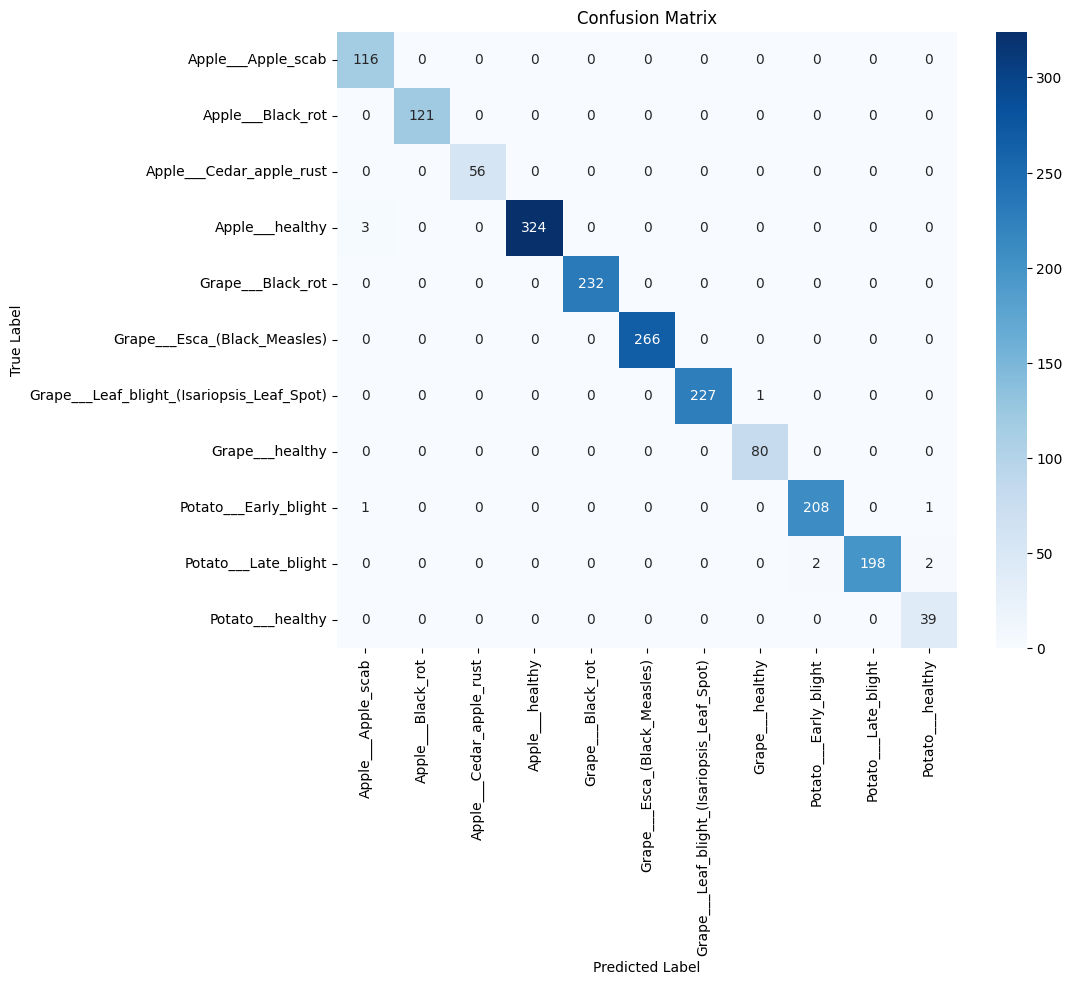

In [ ]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 10. Visualize Training History

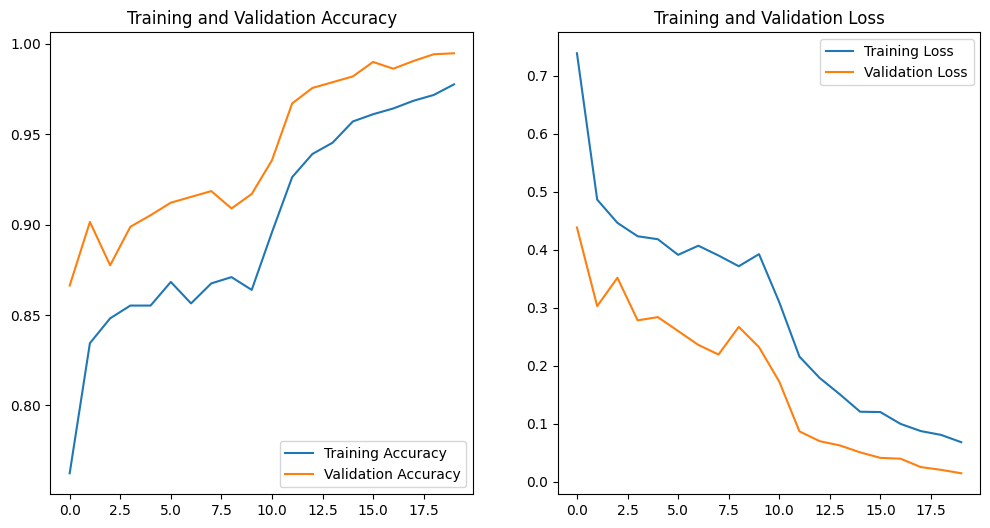

In [ ]:
# Combine histories from both phases for plotting
acc = history_phase1['train_acc'] + history_phase2['train_acc']
val_acc = history_phase1['val_acc'] + history_phase2['val_acc']
loss = history_phase1['train_loss'] + history_phase2['train_loss']
val_loss = history_phase1['val_loss'] + history_phase2['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## 11. Save the Final Model

In [ ]:
# Calculate total training time for each phase
total_time_phase1 = sum(history_phase1['epoch_times'])
total_time_phase2 = sum(history_phase2['epoch_times'])


# The best model is already saved as 'best_model_overall.pth'
# Optionally, save the full model object (architecture + weights + optimizer state)
torch.save({
     'epoch': epoch, # Add current epoch
     'model_state_dict': model.state_dict(),
     'optimizer_state_dict': optimizer_ft.state_dict(), # Use the optimizer from phase 2
     'best_val_acc': best_val_acc_overall, # Add best validation accuracy
     'history_phase1': history_phase1,
     'history_phase2': history_phase2,
     'class_names': class_names,
     'num_classes': num_classes,
     'total_time_phase1': total_time_phase1, # Add total training time for phase 1
     'total_time_phase2': total_time_phase2, # Add total training time for phase 2
     'classifier_state_dict': model.classifier[-1].state_dict() # Add the state dict of the final classifier layer
 }, 'full_model_checkpoint.pth')

# Save only the state dict of the final linear layer of the classifier
# This is redundant now as it's included in the main checkpoint, but kept for clarity if needed separately
# torch.save(model.classifier[-1].state_dict(), 'classifier_state_dict.pth')


print("Model checkpoint saved as 'full_model_checkpoint.pth'")
print("Best overall model saved as 'best_model_overall.pth'") # This was already saved in the training loop
# print("Classifier state dictionary saved as 'classifier_state_dict.pth'") # Removed as it's in the main checkpoint

Model checkpoint saved as 'full_model_checkpoint.pth'
Best overall model saved as 'best_model_overall.pth'


## 12. Test Model with a Single Image

In [ ]:
from google.colab import files

# Download the files
print("Downloading model files...")
files.download('full_model_checkpoint.pth')
files.download('best_model_overall.pth')

print("Download complete.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download complete.


In [ ]:
# Load the full model checkpoint to access history
checkpoint = torch.load('full_model_checkpoint.pth', map_location=device)

history_phase1 = checkpoint['history_phase1']
history_phase2 = checkpoint['history_phase2']
class_names = checkpoint['class_names']
num_classes = checkpoint['num_classes']

print("Training History (Phase 1):")
for epoch in range(len(history_phase1['train_loss'])):
    print(f"Epoch {epoch+1}: Train Loss: {history_phase1['train_loss'][epoch]:.4f}, Train Acc: {history_phase1['train_acc'][epoch]:.4f}, Val Loss: {history_phase1['val_loss'][epoch]:.4f}, Val Acc: {history_phase1['val_acc'][epoch]:.4f}")

print("\nTraining History (Phase 2 - Fine-tuning):")
for epoch in range(len(history_phase2['train_loss'])):
     print(f"Epoch {epoch+1}: Train Loss: {history_phase2['train_loss'][epoch]:.4f}, Train Acc: {history_phase2['train_acc'][epoch]:.4f}, Val Loss: {history_phase2['val_loss'][epoch]:.4f}, Val Acc: {history_phase2['val_acc'][epoch]:.4f}")

# Display the final validation metrics from the evaluation step
# Re-calculate these values as they might not be defined in the current runtime
# Ensure the model is loaded and in evaluation mode
model.load_state_dict(torch.load('best_model_overall.pth', map_location=device))
final_val_loss, final_val_acc, _, _ = validate_one_epoch(model, val_loader, criterion, device)


print(f"\nFinal Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

# Display the total training time (calculated in a previous cell)
# Access the variables directly if the previous cell has been run
if 'total_time_phase1' in locals() and 'total_time_phase2' in locals():
    print(f"\nTotal training time for Phase 1: {total_time_phase1:.2f} seconds")
    print(f"Total training time for Phase 2: {total_time_phase2:.2f} seconds")
    print(f"Total training time overall: {total_time_phase1 + total_time_phase2:.2f} seconds")
else:
    print("\nTotal training time variables not found. Please run the cell that calculates total training time.")

Training History (Phase 1):
Epoch 1: Train Loss: 0.7390, Train Acc: 0.7625, Val Loss: 0.4386, Val Acc: 0.8663
Epoch 2: Train Loss: 0.4867, Train Acc: 0.8344, Val Loss: 0.3030, Val Acc: 0.9014
Epoch 3: Train Loss: 0.4466, Train Acc: 0.8482, Val Loss: 0.3518, Val Acc: 0.8775
Epoch 4: Train Loss: 0.4235, Train Acc: 0.8552, Val Loss: 0.2785, Val Acc: 0.8988
Epoch 5: Train Loss: 0.4183, Train Acc: 0.8552, Val Loss: 0.2840, Val Acc: 0.9052
Epoch 6: Train Loss: 0.3914, Train Acc: 0.8683, Val Loss: 0.2601, Val Acc: 0.9121
Epoch 7: Train Loss: 0.4072, Train Acc: 0.8564, Val Loss: 0.2362, Val Acc: 0.9153
Epoch 8: Train Loss: 0.3903, Train Acc: 0.8675, Val Loss: 0.2196, Val Acc: 0.9185
Epoch 9: Train Loss: 0.3718, Train Acc: 0.8709, Val Loss: 0.2672, Val Acc: 0.9089
Epoch 10: Train Loss: 0.3926, Train Acc: 0.8639, Val Loss: 0.2323, Val Acc: 0.9169

Training History (Phase 2 - Fine-tuning):
Epoch 1: Train Loss: 0.3099, Train Acc: 0.8957, Val Loss: 0.1729, Val Acc: 0.9355
Epoch 2: Train Loss: 0.215

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



Final Validation Accuracy: 0.9947
Final Validation Loss: 0.0148

Total training time for Phase 1: 2359.02 seconds
Total training time for Phase 2: 3826.72 seconds
Total training time overall: 6185.73 seconds


In [ ]:
# Ensure the model is loaded and in evaluation mode
model.load_state_dict(torch.load('best_model_overall.pth', map_location=device))
model.eval()
print("Evaluating model on the entire validation set...")

all_labels = []
all_predictions = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate overall accuracy
overall_accuracy = sum(p == l for p, l in zip(all_predictions, all_labels)) / len(all_labels)
print(f"\nOverall Validation Set Accuracy: {overall_accuracy:.4f}")

Evaluating model on the entire validation set...

Overall Validation Set Accuracy: 0.9947


## 12. Test Model with a Single Image

This section demonstrates how to load the saved model and use it to classify a single image.

Model loaded successfully.

Predicted class: Apple___Cedar_apple_rust
Confidence: 0.9849


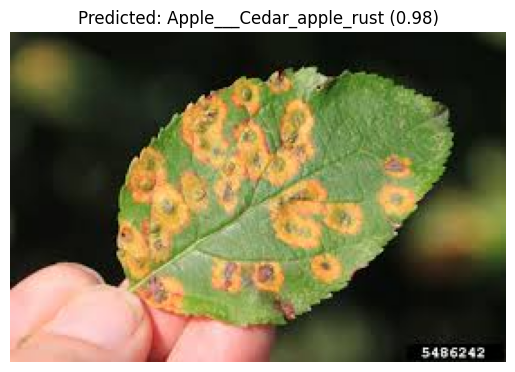

In [ ]:
# --- Load the saved model ---
# Make sure 'best_model_overall.pth' is available in your environment
# If you are running this in a separate notebook, you might need to upload the file
# or adjust the path if it's stored in Google Drive.

model_path = 'best_model_overall.pth' # Or the path to your saved model

# Re-create the model architecture
# Make sure the architecture matches the one used during training (EfficientNetV2-M + custom head)
base_model = timm.create_model('efficientnetv2_rw_m', pretrained=False) # No pretrained weights needed here

# Get the number of input features for the classifier - MUST match training
num_features = base_model.classifier.in_features

# Replace the classifier head - MUST match training
num_classes = 11 # Make sure this matches the number of classes in your training dataset
base_model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(128, num_classes)
)

# Load the saved state dictionary
model = base_model.to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval() # Set the model to evaluation mode

print("Model loaded successfully.")

# --- Load and preprocess the image ---
# You can upload an image or use a path to an existing image file

# Example: Using a placeholder for the image path
# Replace this with the actual path to your image file
image_path = '/content/Apple___Cedar_apple_rust.jpg' # <-- REPLACE with your image path

# You can use google.colab.files.upload() to upload an image in Colab
# uploaded = files.upload()
# for filename in uploaded.keys():
#     image_path = filename
#     print(f"Uploaded file: {image_path}")


if not os.path.exists(image_path):
    print(f"Error: Image file not found at {image_path}")
else:
    # Load the image
    image = Image.open(image_path).convert('RGB')

    # Apply the same transformations used for validation data
    # You need the data_config from the training notebook to recreate the transform
    # Assuming data_config = {'input_size': (3, 320, 320), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 1.0, 'crop_mode': 'center'}
    # Recreate the validation transform
    data_config = {'input_size': (3, 320, 320), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 1.0, 'crop_mode': 'center'}
    transform_val = create_transform(**data_config, is_training=False)

    input_tensor = transform_val(image).unsqueeze(0) # Add batch dimension
    input_tensor = input_tensor.to(device)

    # --- Make a prediction ---
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = F.softmax(output, dim=1)
        _, predicted_class_index = torch.max(probabilities, 1)

    # Get the predicted class name
    # You need the class_names list from the training notebook
    # Assuming class_names are available from the loaded checkpoint or defined manually
    class_names = ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy'] # <-- REPLACE with your actual class names if different

    predicted_class_name = class_names[predicted_class_index.item()]
    confidence = probabilities[0, predicted_class_index.item()].item()

    print(f"\nPredicted class: {predicted_class_name}")
    print(f"Confidence: {confidence:.4f}")

    # Optional: Display the image
    plt.imshow(image)
    plt.title(f"Predicted: {predicted_class_name} ({confidence:.2f})")
    plt.axis('off')
    plt.show()